In [ ]:
# Apple Product Pricing & Market Intelligence Dashboard

## Objective

Analyze Apple product pricing, discounts, ratings, stock availability, and promotional events across multiple e-commerce platforms (2020–2026)
to generate actionable business insights.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- SQL
- Power BI

In [ ]:
# ==========================================================
# Project: Apple Product Pricing & Market Intelligence Dashboard
# Author: Ealham Hossain
# ==========================================================

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# ==========================================================
# Load Dataset
# ==========================================================

from google.colab import files

uploaded = files.upload()

Saving apple_products_pricing_2020_2026.csv to apple_products_pricing_2020_2026.csv


In [ ]:
# Read the CSV file
df = pd.read_csv("apple_products_pricing_2020_2026.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [ ]:
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,NaN,In Stock,4.7,40
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,NaN,Out of Stock,4.6,84
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,NaN,In Stock,4.4,110
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,NaN,In Stock,4.8,111
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,NaN,In Stock,4.7,35


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               80000 non-null  object 
 1   Platform           80000 non-null  object 
 2   Product_Category   80000 non-null  object 
 3   Model_Name         80000 non-null  object 
 4   Condition          80000 non-null  object 
 5   Launch_Price_USD   80000 non-null  int64  
 6   Launch_Price_INR   80000 non-null  int64  
 7   Current_Price_USD  80000 non-null  float64
 8   Current_Price_INR  80000 non-null  float64
 9   Discount_Pct       80000 non-null  float64
 10  Sale_Event         6649 non-null   object 
 11  Stock_Status       80000 non-null  object 
 12  Rating             80000 non-null  float64
 13  Reviews_Count      80000 non-null  int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 8.5+ MB


In [ ]:
rows, cols = df.shape

print(f"Rows    : {rows}")
print(f"Columns : {cols}")

Rows    : 80000
Columns : 14


In [ ]:
df.isnull().sum()

,0
Date,0
Platform,0
Product_Category,0
Model_Name,0
Condition,0
Launch_Price_USD,0
Launch_Price_INR,0
Current_Price_USD,0
Current_Price_INR,0
Discount_Pct,0


In [ ]:
# Replace missing Sale_Event values with "No Sale"
df["Sale_Event"] = df["Sale_Event"].fillna("No Sale")

In [ ]:
df.isnull().sum()

,0
Date,0
Platform,0
Product_Category,0
Model_Name,0
Condition,0
Launch_Price_USD,0
Launch_Price_INR,0
Current_Price_USD,0
Current_Price_INR,0
Discount_Pct,0


In [ ]:
# Check duplicate rows
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 0


In [ ]:
df.dtypes

,0
Date,object
Platform,object
Product_Category,object
Model_Name,object
Condition,object
Launch_Price_USD,int64
Launch_Price_INR,int64
Current_Price_USD,float64
Current_Price_INR,float64
Discount_Pct,float64


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])

In [ ]:
df.dtypes

,0
Date,datetime64[ns]
Platform,object
Product_Category,object
Model_Name,object
Condition,object
Launch_Price_USD,int64
Launch_Price_INR,int64
Current_Price_USD,float64
Current_Price_INR,float64
Discount_Pct,float64


In [ ]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows: {duplicates}")

Duplicate Rows: 0


In [ ]:
print("Product Categories:")
print(df["Product_Category"].unique())

print("\nNumber of Categories:", df["Product_Category"].nunique())

Product Categories:
['Watch' 'iPad' 'iPhone' 'Mac']

Number of Categories: 4


In [ ]:
print("Platforms:")
print(df["Platform"].unique())

print("\nNumber of Platforms:", df["Platform"].nunique())

Platforms:
['Flipkart' 'Amazon']

Number of Platforms: 2


In [ ]:
print("Conditions:")
print(df["Condition"].unique())

Conditions:
['New' 'Renewed/Refurbished']


In [ ]:
print("Stock Status:")
print(df["Stock_Status"].unique())

Stock Status:
['In Stock' 'Out of Stock' 'Low Stock']


In [ ]:
print("Sale Events:")
print(df["Sale_Event"].unique())

Sale Events:
['No Sale' 'Big Billion Days' 'Great Indian Festival' 'Black Friday'
 'Prime Day']


In [ ]:
# Count products in each category
category_counts = df["Product_Category"].value_counts()

category_counts

,count
Product_Category,
iPhone,28589
Mac,18020
Watch,17865
iPad,15526


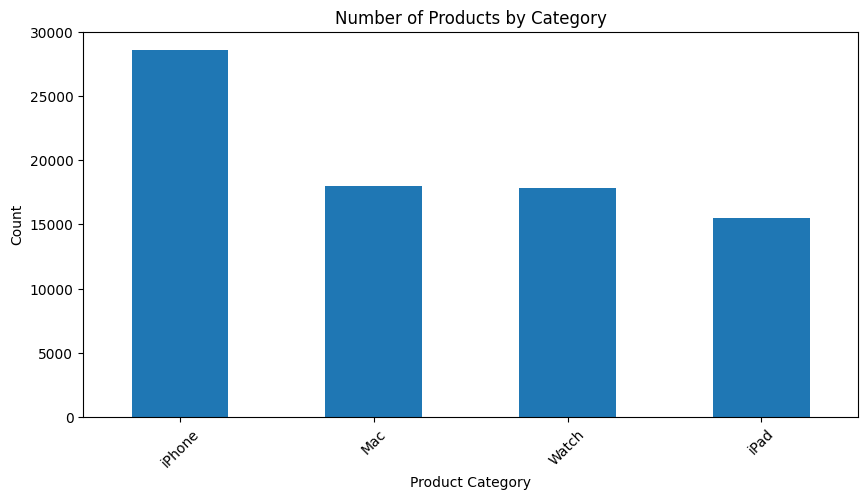

In [ ]:
plt.figure(figsize=(10,5))

category_counts.plot(kind="bar")

plt.title("Number of Products by Category")
plt.xlabel("Product Category")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

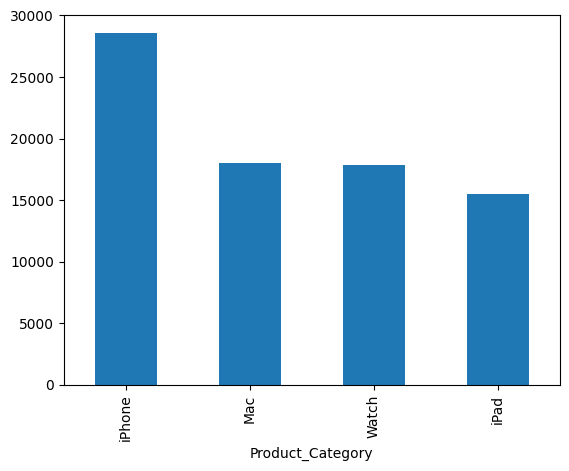

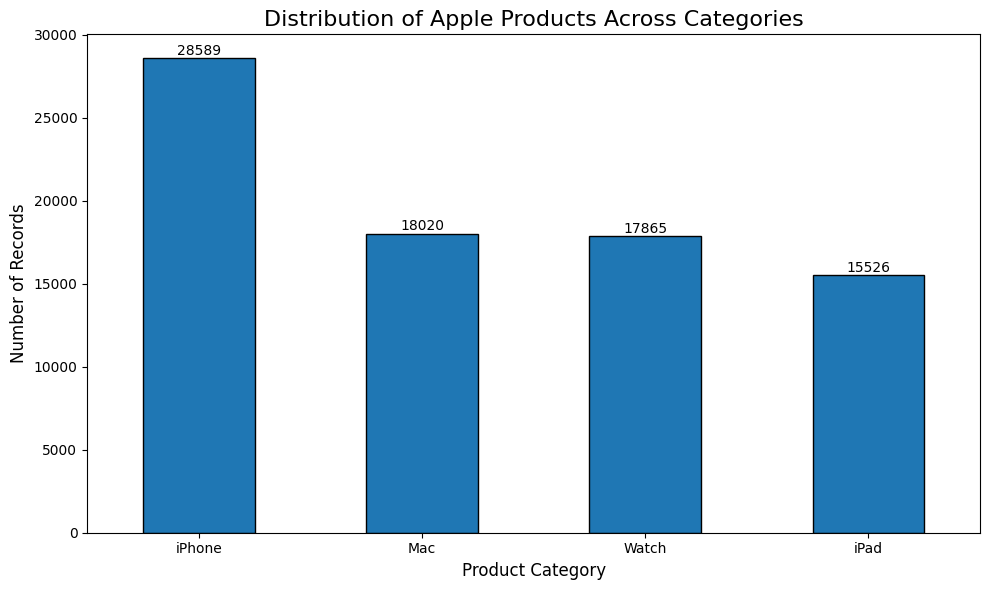

In [ ]:
category_counts.plot(kind="bar")
plt.figure(figsize=(10,6))

category_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Distribution of Apple Products Across Categories", fontsize=16)
plt.xlabel("Product Category", fontsize=12)
plt.ylabel("Number of Records", fontsize=12)
plt.xticks(rotation=0)

# Add value labels on top of each bar
for index, value in enumerate(category_counts):
    plt.text(index, value + 200, str(value), ha='center', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:

# Which platform offers the highest average discount?


platform_discount = (
    df.groupby("Platform")["Discount_Pct"]
      .mean()
      .sort_values(ascending=False)
)

platform_discount

,Discount_Pct
Platform,
Amazon,21.515399
Flipkart,21.322461


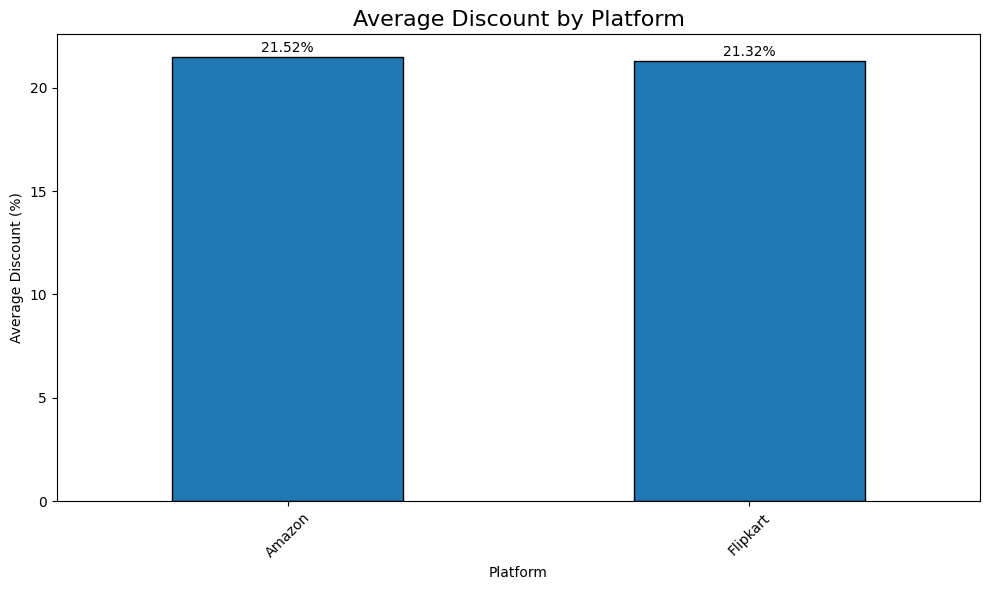

In [ ]:
plt.figure(figsize=(10,6))

platform_discount.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Discount by Platform", fontsize=16)
plt.xlabel("Platform")
plt.ylabel("Average Discount (%)")

plt.xticks(rotation=45)

for index, value in enumerate(platform_discount):
    plt.text(index, value + 0.2, f"{value:.2f}%", ha="center")

plt.tight_layout()

plt.show()

In [ ]:

# Which product category offers the highest average discount?


category_discount = (
    df.groupby("Product_Category")["Discount_Pct"]
      .mean()
      .sort_values(ascending=False)
)

category_discount

,Discount_Pct
Product_Category,
Watch,26.266779
iPad,26.189856
iPhone,19.572790
Mac,15.430627


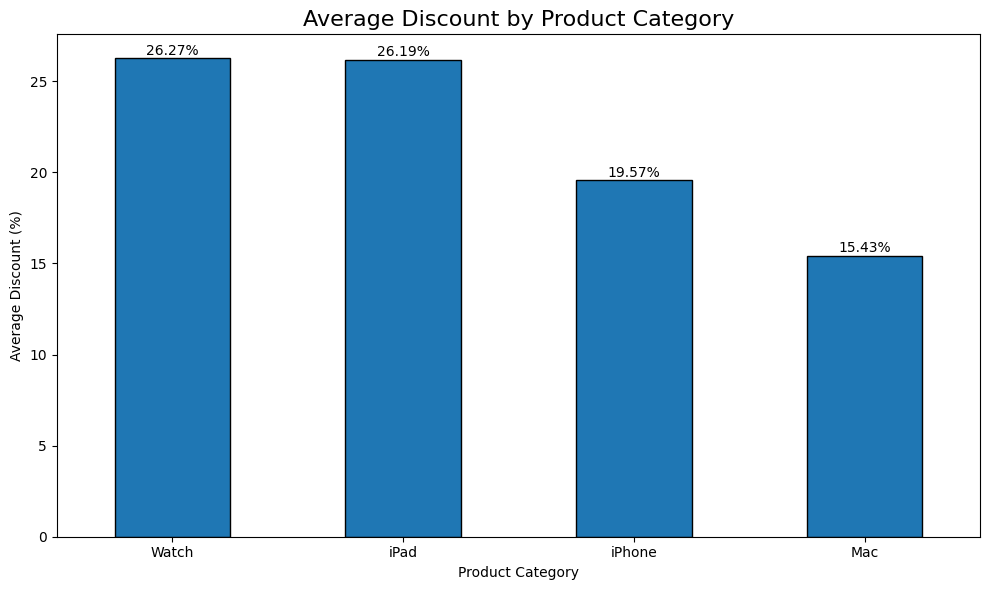

In [ ]:
plt.figure(figsize=(10,6))

category_discount.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Discount by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Average Discount (%)")

plt.xticks(rotation=0)

for index, value in enumerate(category_discount):
    plt.text(index, value + 0.2, f"{value:.2f}%", ha="center")

plt.tight_layout()

plt.show()

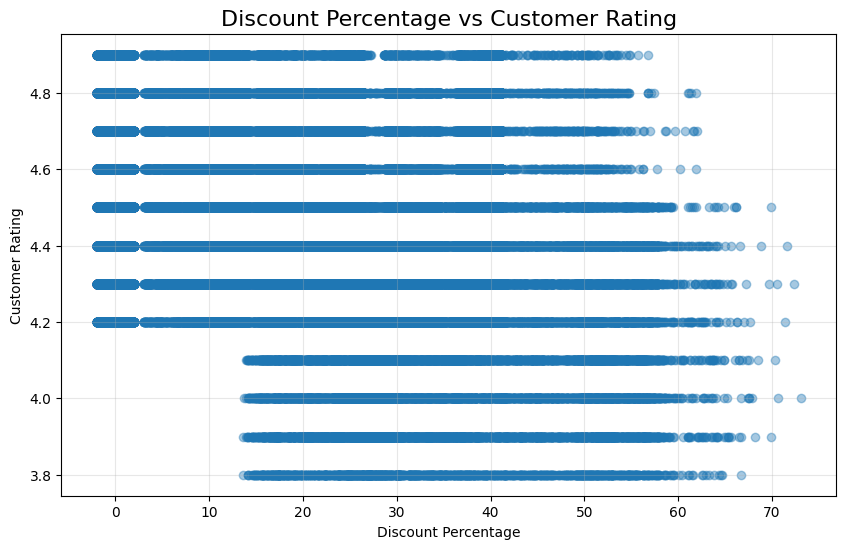

In [ ]:

# Do higher discounts lead to better customer ratings?


plt.figure(figsize=(10,6))

plt.scatter(
    df["Discount_Pct"],
    df["Rating"],
    alpha=0.4
)

plt.title("Discount Percentage vs Customer Rating", fontsize=16)
plt.xlabel("Discount Percentage")
plt.ylabel("Customer Rating")

plt.grid(alpha=0.3)

plt.show()

In [ ]:

# Which platform sells Apple products at the highest average price?

platform_price = (
    df.groupby("Platform")["Current_Price_USD"]
      .mean()
      .sort_values(ascending=False)
)

platform_price

,Current_Price_USD
Platform,
Amazon,783.968025
Flipkart,781.574259


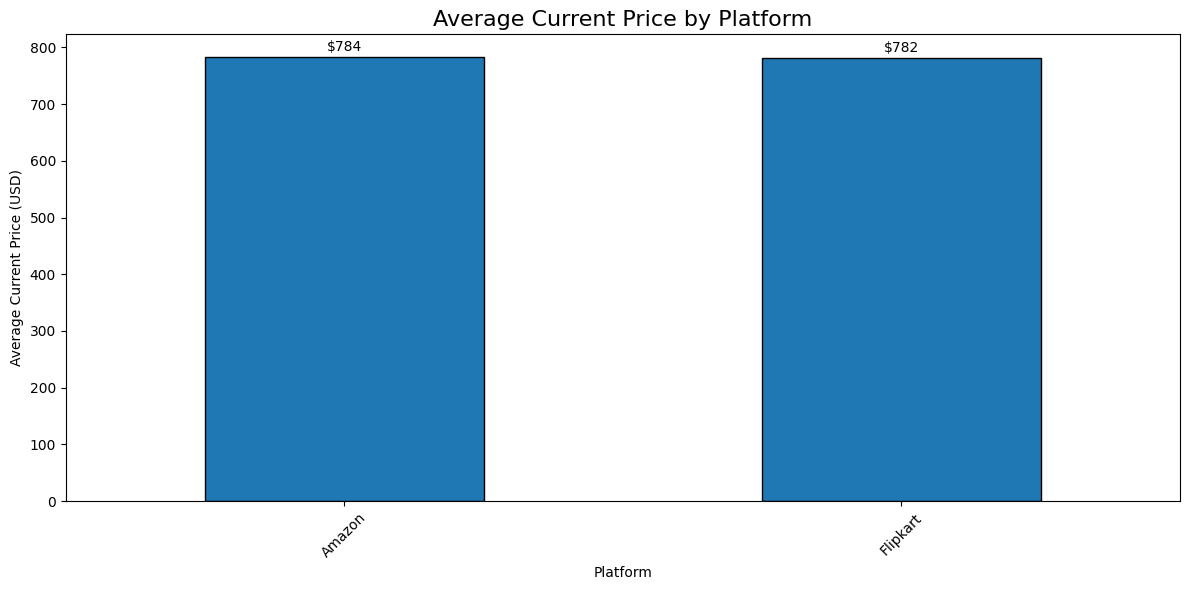

In [ ]:
plt.figure(figsize=(12,6))

platform_price.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Current Price by Platform", fontsize=16)
plt.xlabel("Platform")
plt.ylabel("Average Current Price (USD)")

plt.xticks(rotation=45)

for index, value in enumerate(platform_price):
    plt.text(index, value + 10, f"${value:.0f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:

# Calculate Price Depreciation


df["Price_Drop_USD"] = (
    df["Launch_Price_USD"] -
    df["Current_Price_USD"]
)

df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Price_Drop_USD
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,No Sale,In Stock,4.7,40,-6.81
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,No Sale,Out of Stock,4.6,84,-7.49
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,No Sale,In Stock,4.4,110,6.27
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,No Sale,In Stock,4.8,111,4.00
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,No Sale,In Stock,4.7,35,-7.22


In [ ]:
df[[
    "Model_Name",
    "Launch_Price_USD",
    "Current_Price_USD",
    "Price_Drop_USD"
]].head()

,Model_Name,Launch_Price_USD,Current_Price_USD,Price_Drop_USD
0,Apple Watch Series 6 (44mm),429,435.81,-6.81
1,Apple Watch Series 6 (44mm),429,436.49,-7.49
2,Apple Watch Series 6 (44mm),429,422.73,6.27
3,Apple Watch Series 6 (44mm),429,425.00,4.00
4,Apple Watch Series 6 (44mm),429,436.22,-7.22


In [ ]:
price_drop = (
    df.groupby("Product_Category")["Price_Drop_USD"]
      .mean()
      .sort_values(ascending=False)
)

price_drop

,Price_Drop_USD
Product_Category,
Mac,229.823173
iPhone,182.012645
iPad,176.740397
Watch,134.682177


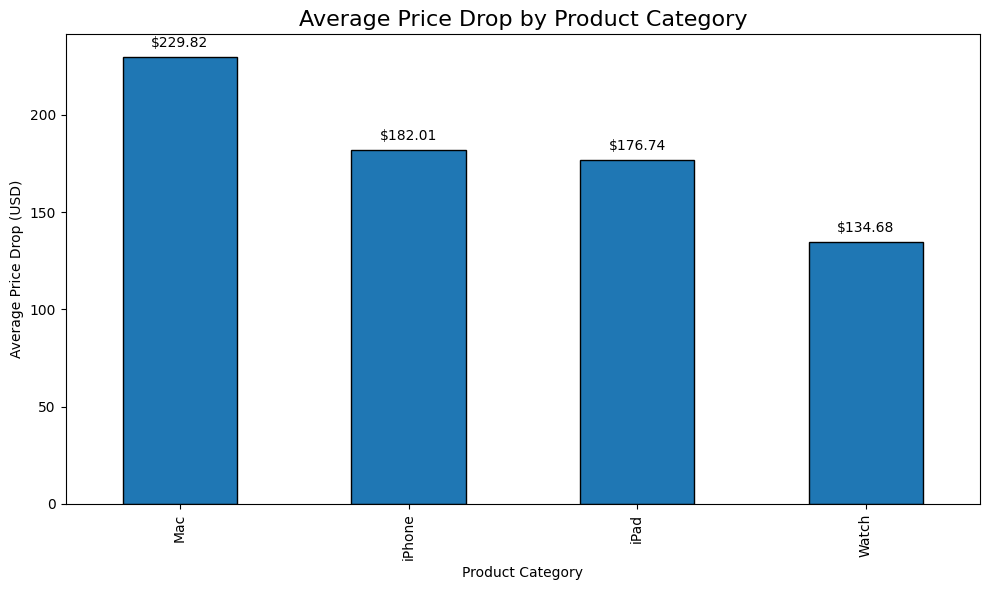

In [ ]:
plt.figure(figsize=(10,6))

price_drop.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Price Drop by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Average Price Drop (USD)")

for index, value in enumerate(price_drop):
    plt.text(index, value + 5, f"${value:.2f}", ha="center")

plt.tight_layout()

plt.show()

In [ ]:

# Price Retention Percentage


df["Price_Retention_Pct"] = (
    df["Current_Price_USD"] /
    df["Launch_Price_USD"]
) * 100

In [ ]:
df[[
    "Model_Name",
    "Launch_Price_USD",
    "Current_Price_USD",
    "Price_Retention_Pct"
]].head()

,Model_Name,Launch_Price_USD,Current_Price_USD,Price_Retention_Pct
0,Apple Watch Series 6 (44mm),429,435.81,101.587413
1,Apple Watch Series 6 (44mm),429,436.49,101.745921
2,Apple Watch Series 6 (44mm),429,422.73,98.538462
3,Apple Watch Series 6 (44mm),429,425.00,99.067599
4,Apple Watch Series 6 (44mm),429,436.22,101.682984


In [ ]:
retention = (
    df.groupby("Product_Category")["Price_Retention_Pct"]
      .mean()
      .sort_values(ascending=False)
)

retention

,Price_Retention_Pct
Product_Category,
Mac,84.569416
iPhone,80.427242
iPad,73.810264
Watch,73.733250


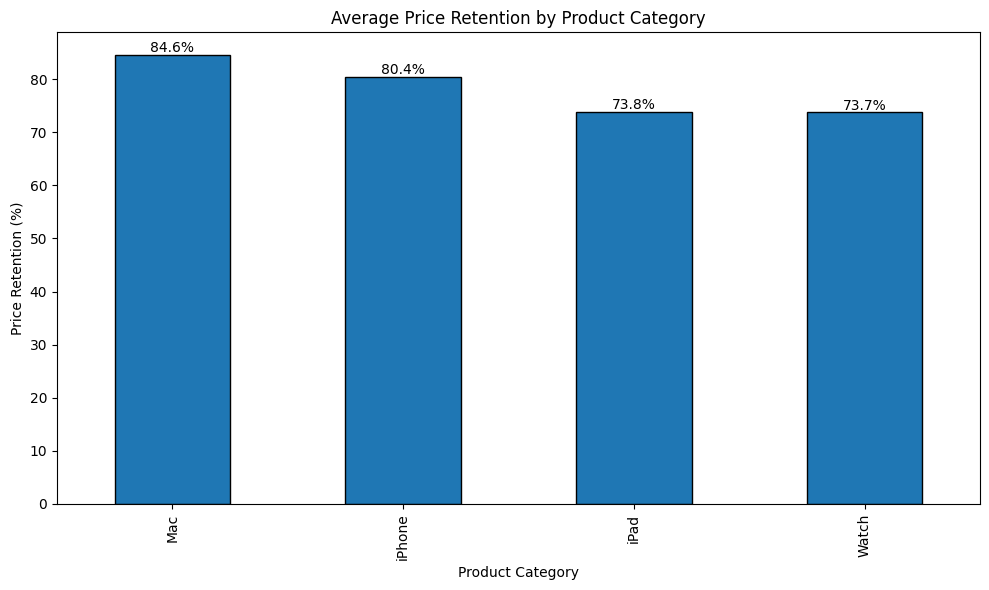

In [ ]:
plt.figure(figsize=(10,6))

retention.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Price Retention by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Price Retention (%)")

for i, value in enumerate(retention):
    plt.text(i, value + 0.5, f"{value:.1f}%", ha="center")

plt.tight_layout()
plt.show()

In [ ]:

# Which product category has the highest average customer rating?


category_rating = (
    df.groupby("Product_Category")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

category_rating

,Rating
Product_Category,
iPhone,4.451240
Mac,4.450461
iPad,4.449916
Watch,4.448066


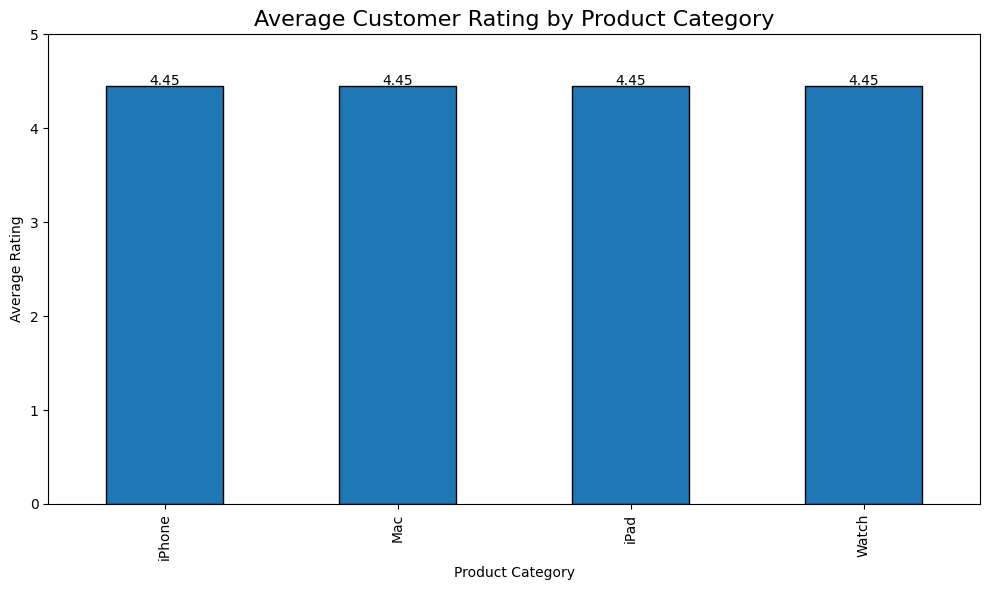

In [ ]:
plt.figure(figsize=(10,6))

category_rating.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Customer Rating by Product Category", fontsize=16)
plt.xlabel("Product Category")
plt.ylabel("Average Rating")

for index, value in enumerate(category_rating):
    plt.text(index, value + 0.01, f"{value:.2f}", ha="center")

plt.ylim(0,5)

plt.tight_layout()

plt.show()

In [ ]:

# Which sale events provide the highest discounts?


sale_discount = (
    df.groupby("Sale_Event")["Discount_Pct"]
      .mean()
      .sort_values(ascending=False)
)

sale_discount

,Discount_Pct
Sale_Event,
Big Billion Days,37.023686
Prime Day,34.435734
Great Indian Festival,33.446077
Black Friday,31.462155
No Sale,20.304699


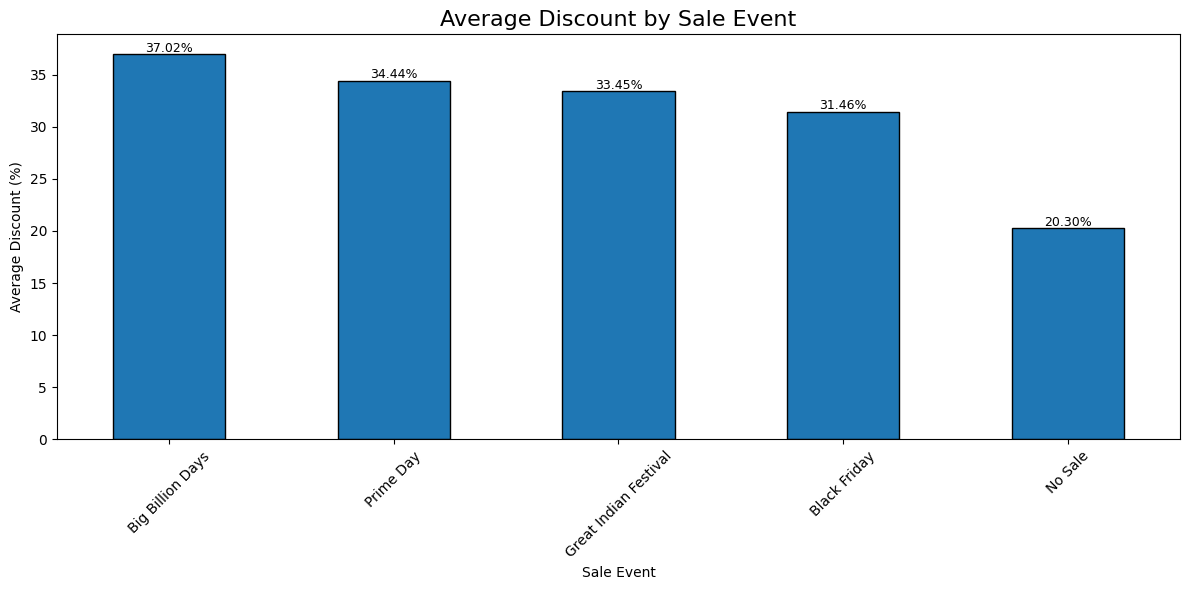

In [ ]:
plt.figure(figsize=(12,6))

sale_discount.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Discount by Sale Event", fontsize=16)
plt.xlabel("Sale Event")
plt.ylabel("Average Discount (%)")

plt.xticks(rotation=45)

for index, value in enumerate(sale_discount):
    plt.text(index, value + 0.2, f"{value:.2f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:

#  KPIs


total_products = len(df)

total_categories = df["Product_Category"].nunique()

total_platforms = df["Platform"].nunique()

average_rating = df["Rating"].mean()

average_discount = df["Discount_Pct"].mean()

average_price = df["Current_Price_USD"].mean()

In [ ]:
print("="*50)
print("EXECUTIVE KPI SUMMARY")
print("="*50)

print(f"Total Records      : {total_products:,}")
print(f"Product Categories : {total_categories}")
print(f"Platforms          : {total_platforms}")
print(f"Average Rating     : {average_rating:.2f}")
print(f"Average Discount   : {average_discount:.2f}%")
print(f"Average Price      : ${average_price:.2f}")

EXECUTIVE KPI SUMMARY
Total Records      : 80,000
Product Categories : 4
Platforms          : 2
Average Rating     : 4.45
Average Discount   : 21.42%
Average Price      : $782.77


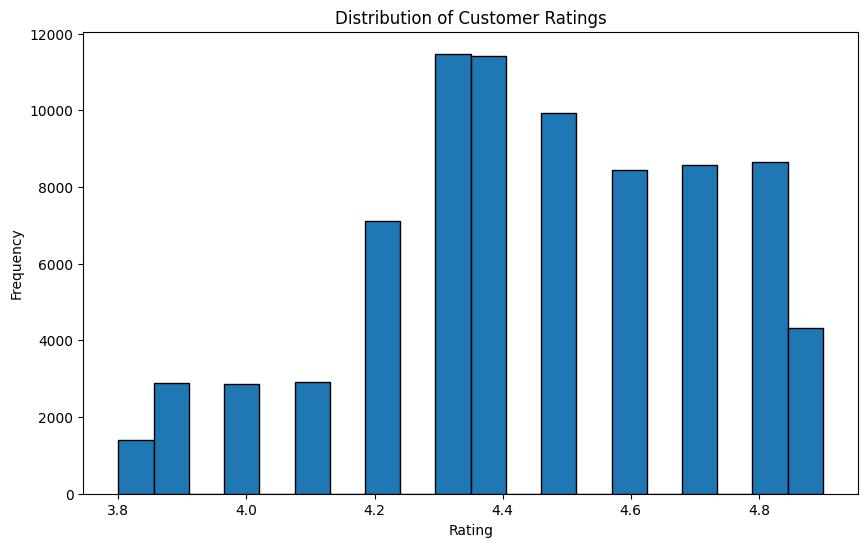

In [ ]:

# EDA
# Distribution of Customer Ratings


plt.figure(figsize=(10,6))

plt.hist(
    df["Rating"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()

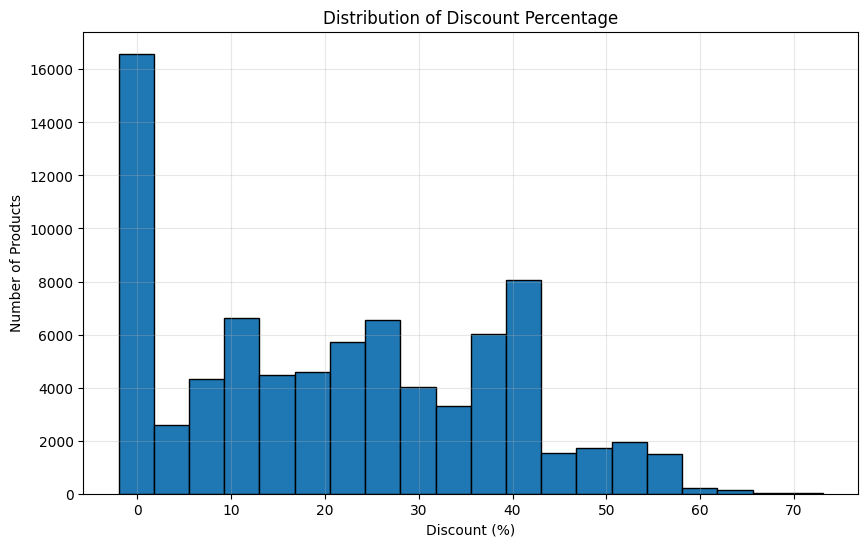

In [ ]:

# EDA 1: Distribution of Discounts


plt.figure(figsize=(10,6))

plt.hist(
    df["Discount_Pct"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Discount Percentage")
plt.xlabel("Discount (%)")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.show()

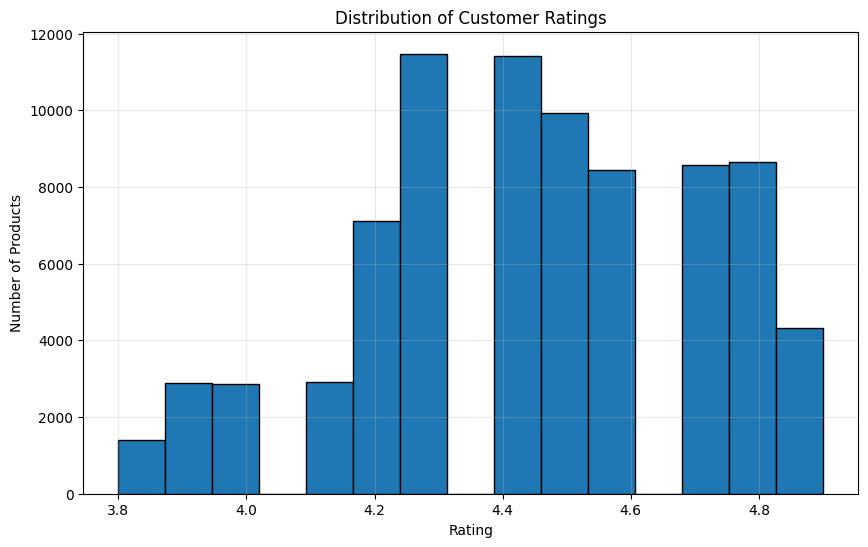

In [ ]:

# EDA 2: Distribution of Ratings


plt.figure(figsize=(10,6))

plt.hist(
    df["Rating"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.grid(alpha=0.3)

plt.show()

In [ ]:

# EDA 3: Correlation Matrix


correlation = df[
    [
        "Launch_Price_USD",
        "Current_Price_USD",
        "Discount_Pct",
        "Rating",
        "Reviews_Count"
    ]
].corr()

print(correlation)

                   Launch_Price_USD  Current_Price_USD  Discount_Pct    Rating  Reviews_Count
Launch_Price_USD           1.000000           0.947179     -0.322066 -0.001760      -0.096096
Current_Price_USD          0.947179           1.000000     -0.574824  0.110571      -0.265293
Discount_Pct              -0.322066          -0.574824      1.000000 -0.310257       0.615356
Rating                    -0.001760           0.110571     -0.310257  1.000000       0.003413
Reviews_Count             -0.096096          -0.265293      0.615356  0.003413       1.000000


In [ ]:

# Feature Engineering


# Price Drop
df["Price_Drop_USD"] = (
    df["Launch_Price_USD"] -
    df["Current_Price_USD"]
)

# Price Retention Percentage
df["Price_Retention_Pct"] = (
    df["Current_Price_USD"] /
    df["Launch_Price_USD"]
) * 100

# Discount Amount in USD
df["Discount_Amount_USD"] = (
    df["Launch_Price_USD"] *
    df["Discount_Pct"] / 100
)

In [ ]:
df.head()

,Date,Platform,Product_Category,Model_Name,Condition,Launch_Price_USD,Launch_Price_INR,Current_Price_USD,Current_Price_INR,Discount_Pct,Sale_Event,Stock_Status,Rating,Reviews_Count,Price_Drop_USD,Price_Retention_Pct,Discount_Amount_USD
0,2020-09-19,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,435.81,43322.41,-1.6,No Sale,In Stock,4.7,40,-6.81,101.587413,-6.864
1,2020-09-20,Flipkart,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.49,42320.43,-1.7,No Sale,Out of Stock,4.6,84,-7.49,101.745921,-7.293
2,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,422.73,40879.36,1.5,No Sale,In Stock,4.4,110,6.27,98.538462,6.435
3,2020-09-23,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,425.00,42008.70,0.9,No Sale,In Stock,4.8,111,4.00,99.067599,3.861
4,2020-09-24,Amazon,Watch,Apple Watch Series 6 (44mm),New,429,42042,436.22,41984.28,-1.7,No Sale,In Stock,4.7,35,-7.22,101.682984,-7.293


In [ ]:


### Objective
Which platform offers the highest average discount?

### Business Context
Understanding platform-wise discounts helps Apple evaluate pricing strategies across different e-commerce platforms.

In [ ]:
platform_discount = (
    df.groupby("Platform")["Discount_Pct"]
      .mean()
      .sort_values(ascending=False)
)

platform_discount

,Discount_Pct
Platform,
Amazon,21.515399
Flipkart,21.322461


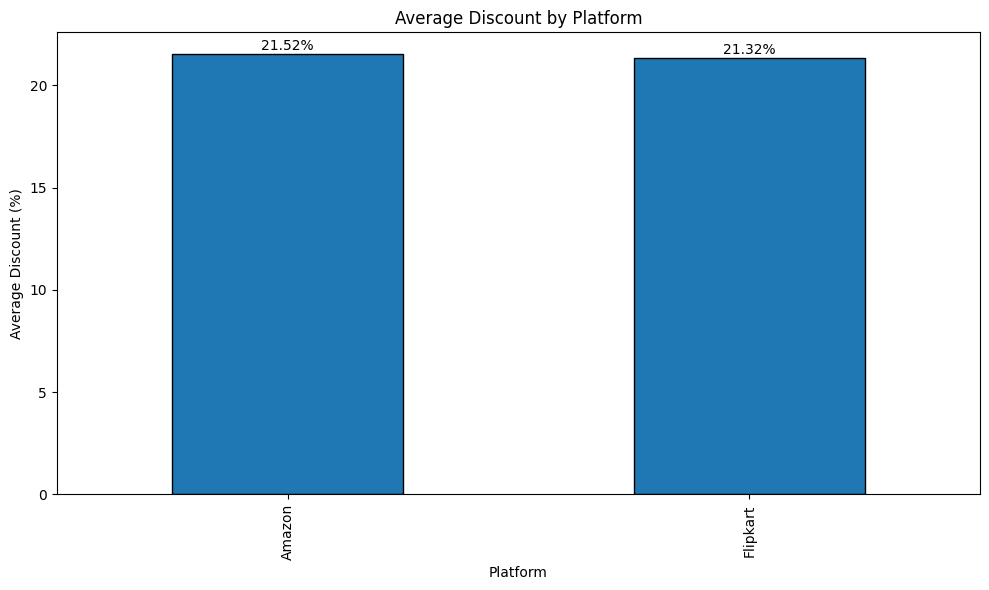

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

platform_discount.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Average Discount by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Discount (%)")

for i, value in enumerate(platform_discount):
    plt.text(i, value + 0.2, f"{value:.2f}%", ha="center")

plt.tight_layout()
plt.show()

In [ ]:
category_discount = (
    df.groupby("Product_Category")["Discount_Pct"]
      .mean()
      .sort_values(ascending=False)
)

category_discount

,Discount_Pct
Product_Category,
Watch,26.266779
iPad,26.189856
iPhone,19.572790
Mac,15.430627


In [ ]:
platform_price = (
    df.groupby("Platform")["Current_Price_USD"]
      .mean()
      .sort_values(ascending=False)
)

platform_price

,Current_Price_USD
Platform,
Amazon,783.968025
Flipkart,781.574259


In [ ]:
retention = (
    df.groupby("Product_Category")["Price_Retention_Pct"]
      .mean()
      .sort_values(ascending=False)
)

retention

,Price_Retention_Pct
Product_Category,
Mac,84.569416
iPhone,80.427242
iPad,73.810264
Watch,73.733250


In [ ]:
category_rating = (
    df.groupby("Product_Category")["Rating"]
      .mean()
      .sort_values(ascending=False)
)

category_rating

,Rating
Product_Category,
iPhone,4.451240
Mac,4.450461
iPad,4.449916
Watch,4.448066


In [ ]:
top_reviews = (
    df.groupby("Model_Name")["Reviews_Count"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_reviews

,Reviews_Count
Model_Name,
iPhone 12 Pro 128GB,9695181
iPad Air (4th Gen) 64GB,9610122
Apple Watch Series 6 (44mm),9432985
MacBook Air M1 256GB,9408082
iPhone 12 64GB,9281382
iPad Pro 11-inch (M1) 128GB,8765377
Apple Watch Series 7 (45mm),8006933
iPad (9th Gen) 64GB,7942664
iPhone 13 128GB,7922712


In [ ]:

# Executive KPI Summary


print("="*60)
print("APPLE PRODUCT PRICING ANALYTICS - EXECUTIVE SUMMARY")
print("="*60)

print(f"Total Records           : {len(df):,}")
print(f"Platforms               : {df['Platform'].nunique()}")
print(f"Product Categories      : {df['Product_Category'].nunique()}")
print(f"Average Rating          : {df['Rating'].mean():.2f}")
print(f"Average Discount (%)    : {df['Discount_Pct'].mean():.2f}")
print(f"Average Current Price   : ${df['Current_Price_USD'].mean():.2f}")
print(f"Average Price Retention : {df['Price_Retention_Pct'].mean():.2f}%")

APPLE PRODUCT PRICING ANALYTICS - EXECUTIVE SUMMARY
Total Records           : 80,000
Platforms               : 2
Product Categories      : 4
Average Rating          : 4.45
Average Discount (%)    : 21.42
Average Current Price   : $782.77
Average Price Retention : 78.58%


In [ ]:
# Executive Summary

## Project Overview

This project analyzes Apple product pricing across multiple e-commerce platforms from 2020–2026.

The objective is to evaluate pricing strategies, promotional discounts, customer satisfaction, and product performance to support data driven business decisions.

---

## Key Findings

- The dataset contains over 80,000 product records.
- Apple Watch and iPad receive the highest average discounts.
- Mac products retain their value better than other categories.
- Customer ratings remain consistently high across platforms.
- Promotional events significantly influence discount percentages.

---

## Business Recommendations

- Continue premium pricing for products with high customer ratings and strong price retention.
- Evaluate promotional strategies during major sale events.
- Optimize inventory planning before high discount campaigns.
- Monitor pricing consistency across online platforms.

In [66]:
import os

print(os.getcwd())
print(os.listdir())

/content
['.config', 'apple_products_pricing_2020_2026.csv', 'cleaned_data.csv', 'sample_data']


In [67]:
df.to_csv("cleaned_data.csv", index=False)
print("File saved!")

File saved!


In [68]:
!ls

apple_products_pricing_2020_2026.csv  cleaned_data.csv	sample_data


In [69]:
from google.colab import files

files.download("cleaned_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>